<a href="https://colab.research.google.com/github/nieko1/Arctic-Hydrology-Assignment-/blob/main/Colab1_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab 1 — Samoylov landscape structure and summer water balance

In this first exercise, we use the polygonal tundra of **Samoylov Island in the Lena River Delta** to understand how small-scale landscape structure can influence hydrological functioning. For the paper by Helbig et al. (2013) click [here](https://d1wqtxts1xzle7.cloudfront.net/41227294/Spatial_and_seasonal_variability_of_poly20160114-28513-1pd2aqm.pdf20160115-19908-5n0ea6-libre.pdf?1452885728=&response-content-disposition=inline%3B+filename%3DSpatial_and_seasonal_variability_of_poly.pdf&Expires=1788717636&Signature=KOCLBgPt6NA~NvpPhISZP8~0XzzKqOBBJtYy6ORXnSZi0mDpLVQC3xYmKWveQXMxe1ouqNN9LHFsm9LS3oRupD8qEiJCdt3iH8KpYWOUHtq5TiMgJ7~YwQjw7ln5XjuO3pQWkR9YEOS~bSGuDbdbifnQzf5V0BBaKHKX5vNqTs9acJOkm~t7EsmaMvXCvPQf9O5gkHj7t9EGi6hJWLInZwAKzoRZ-0sLMYVz~arS98anVWKpT0TcXbonsL54xLLgBK96h8eDpt3942SXuAJqj8aYSVvkYhr36eQ9EXAfO9Kda6~QSfIkBeZm4DtYrh3pXXAzad08~Y8Pi7iv17VMbw__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA).

We will focus on two components of the summer water balance:

1. the relative abundance of **wet and dry surfaces** within the catchment;
2. the balance between **precipitation and evapotranspiration** over these surfaces.

These calculations provide a first estimate of how much water may remain available for storage or lateral transport during summer.

In the next Colab exercise, we will add the effects of **seasonal thaw and lateral hydrological connectivity**.

## Learning objective

By the end of this notebook, you should be able to explain how the spatial organization of wet and dry polygon surfaces influences the summer water balance of a polygonal-tundra catchment.

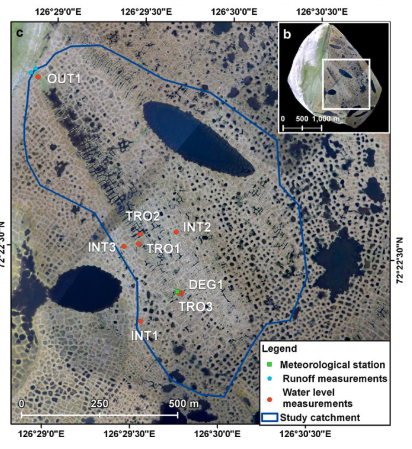

## 1. The Samoylov catchment

Samoylov Island is located in the Lena River Delta in northern Siberia. The study catchment is a small, very low-gradient catchment underlain by continuous permafrost and dominated by polygonal tundra.

At first glance the landscape appears almost flat. At the scale of individual ice-wedge polygons, however, small elevation differences separate relatively **dry elevated surfaces** from **wet depressions, troughs, ponds, and polygon centres**.

These small differences in surface elevation strongly influence where water can be stored and how easily it can move through the landscape.

### Before starting the analysis

Inspect the image of the catchment.

**Question 1**

What landscape features do you expect to be important for the summer water balance?

Think specifically about:

- where water is likely to accumulate;
- which surfaces are likely to be relatively dry;
- which parts of the landscape may restrict or promote lateral flow.

Write down 2–3 observations before continuing.

 ## 2. Quantifying wet and dry surfaces

The first step is to quantify how much of the catchment consists of relatively **wet** and **dry** surfaces.

A classified raster derived from aerial imagery divides the surface into four classes:

| Class | Interpretation |
|---|---|
| Submerged vegetation | Vegetated surface covered by shallow water |
| Dry | Relatively dry and elevated surface |
| Wet | Wet surface, including polygon-centre-like areas |
| Water | Open water |

We will use the catchment boundary to clip this raster and calculate the surface area occupied by each class.

### Why does this matter?

The relative abundance of wet and dry surfaces affects the catchment water balance because these surfaces can differ in:

- evapotranspiration;
- water storage;
- surface and subsurface connectivity.

For the simplified calculations later in this notebook, we will treat the **dry** and **wet** classes as two contrasting hydrological surface types.

In [ ]:
# Import packages
import geopandas as gpd
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt

# File locations
catchment_file = "catchment.geojson"
classification_file = "samoylov_surface_classification_lowres.tif"

# Load the catchment boundary
catchment = gpd.read_file(catchment_file)

# Inspect the basic information
print("Catchment CRS:", catchment.crs)
print("Number of catchment polygons:", len(catchment))

In [1]:
!pip -q install rasterio fiona descartes

import rasterio
import rasterio.plot
import rasterio.mask

import pyproj
import numpy as np
import matplotlib.pyplot as plt

import fiona

from matplotlib import pyplot
from descartes import PolygonPatch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 38.2 MB/s eta 0:00:00
